In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, NuSVC, OneClassSVM
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import GridSearchCV
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('SBAnational.csv')

/tmp/ipykernel_2221/2640212651.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('SBAnational.csv')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  object 
 2   City               899134 non-null  object 
 3   State              899150 non-null  object 
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  object 
 6   BankState          897598 non-null  object 
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  object 
 9   ApprovalFY         899164 non-null  object 
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  Ur

In [ ]:
df.head(5).T

,0,1,2,3,4
LoanNr_ChkDgt,1000014003,1000024006,1000034009,1000044001,1000054004
Name,ABC HOBBYCRAFT,LANDMARK BAR & GRILLE (THE),"WHITLOCK DDS, TODD M.","BIG BUCKS PAWN & JEWELRY, LLC","ANASTASIA CONFECTIONS, INC."
City,EVANSVILLE,NEW PARIS,BLOOMINGTON,BROKEN ARROW,ORLANDO
State,IN,IN,IN,OK,FL
Zip,47711,46526,47401,74012,32801
Bank,FIFTH THIRD BANK,1ST SOURCE BANK,GRANT COUNTY STATE BANK,1ST NATL BK & TR CO OF BROKEN,FLORIDA BUS. DEVEL CORP
BankState,OH,IN,IN,OK,FL
NAICS,451120,722410,621210,0,0
ApprovalDate,28-Feb-97,28-Feb-97,28-Feb-97,28-Feb-97,28-Feb-97
ApprovalFY,1997,1997,1997,1997,1997


In [ ]:
df.describe()

,LoanNr_ChkDgt,Zip,NAICS,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural
count,8.991640e+05,899164.000000,899164.000000,899164.000000,899164.000000,899028.000000,899164.000000,899164.000000,899164.000000,899164.000000
mean,4.772612e+09,53804.391241,398660.950146,110.773078,11.411353,1.280404,8.430376,10.797257,2753.725933,0.757748
std,2.538175e+09,31184.159152,263318.312759,78.857305,74.108196,0.451750,236.688165,237.120600,12758.019136,0.646436
min,1.000014e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.589758e+09,27587.000000,235210.000000,60.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,4.361439e+09,55410.000000,445310.000000,84.000000,4.000000,1.000000,0.000000,1.000000,1.000000,1.000000
75%,6.904627e+09,83704.000000,561730.000000,120.000000,10.000000,2.000000,1.000000,4.000000,1.000000,1.000000
max,9.996003e+09,99999.000000,928120.000000,569.000000,9999.000000,2.000000,8800.000000,9500.000000,99999.000000,2.000000


In [ ]:
df.columns

Index(['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState',
       'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist',
       'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr',
       'LowDoc', 'ChgOffDate', 'DisbursementDate', 'DisbursementGross',
       'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv'],
      dtype='object')

In [ ]:
df.shape

(899164, 27)

In [ ]:
print(df.dtypes)
# print('\n')
#print(df.isnull().sum())

LoanNr_ChkDgt          int64
Name                  object
City                  object
State                 object
Zip                    int64
Bank                  object
BankState             object
NAICS                  int64
ApprovalDate          object
ApprovalFY            object
Term                   int64
NoEmp                  int64
NewExist             float64
CreateJob              int64
RetainedJob            int64
FranchiseCode          int64
UrbanRural             int64
RevLineCr             object
LowDoc                object
ChgOffDate            object
DisbursementDate      object
DisbursementGross    float64
BalanceGross         float64
MIS_Status            object
ChgOffPrinGr         float64
GrAppv               float64
SBA_Appv             float64
dtype: object


In [ ]:
currency_cols = ['DisbursementGross', 'BalanceGross',
                 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']

for col in currency_cols:
    df[col] = df[col].replace('[\$,]', '', regex=True).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[currency_cols].dtypes)

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2221/3513126400.py:5: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace('[\$,]', '', regex=True).str.strip()


DisbursementGross    float64
BalanceGross         float64
ChgOffPrinGr         float64
GrAppv               float64
SBA_Appv             float64
dtype: object


In [ ]:
#Drop the Nulls
# These columns we allow to have nulls
allow_nulls = ['NoEmp', 'CreateJob', 'RetainedJob', 'ChgOffDate']

# Drop nulls in all other columns
cols_to_check = [c for c in df.columns if c not in allow_nulls]
before = len(df)
df = df.dropna(subset=cols_to_check)
print(f'Dropped {before - len(df):,} rows with nulls')
print(f'Remaining: {len(df):,}')

Dropped 12,924 rows with nulls
Remaining: 886,240


In [ ]:
# drop invalid rows
before = len(df)

# City, Zip, NAICS only contain a single digit
df = df[df['City'].str.len() > 1]
df = df[df['Zip'].astype(str).str.len() > 1]
df = df[df['NAICS'].astype(str).str.len() > 1]

# ApprovalFY only contains letters
df = df[pd.to_numeric(df['ApprovalFY'], errors='coerce').notna()]

# Term is 0
df = df[df['Term'] != 0]

# NewExist must be 1 or 2
df = df[df['NewExist'].isin([1, 2])]

# RevLineCr must be Y or N
df = df[df['RevLineCr'].isin(['Y', 'N'])]

# LowDoc must be Y or N
df = df[df['LowDoc'].isin(['Y', 'N'])]

print(f'Dropped {before - len(df):,} invalid rows')
print(f'Remaining: {len(df):,}')

Dropped 429,966 invalid rows
Remaining: 456,274


In [ ]:
df['NAICS_2Digit_Code'] = df['NAICS'].astype(str).str[:2].astype(int)

naics_titles = {
    11: 'Agriculture, Forestry, Fishing',
    21: 'Mining, Quarrying, Oil and Gas',
    22: 'Utilities',
    23: 'Construction',
    31: 'Manufacturing', 32: 'Manufacturing', 33: 'Manufacturing',
    42: 'Wholesale Trade',
    44: 'Retail Trade', 45: 'Retail Trade',
    48: 'Transportation and Warehousing', 49: 'Transportation and Warehousing',
    51: 'Information',
    52: 'Finance and Insurance',
    53: 'Real Estate',
    54: 'Professional, Scientific, Technical',
    55: 'Management of Companies',
    56: 'Administrative and Support',
    61: 'Educational Services',
    62: 'Health Care and Social Assistance',
    71: 'Arts, Entertainment, Recreation',
    72: 'Accommodation and Food Services',
    81: 'Other Services',
    92: 'Public Administration'
}

df['NAICS_2Digit_Title'] = df['NAICS_2Digit_Code'].map(naics_titles)
df = df.dropna(subset=['NAICS_2Digit_Title'])

print(df['NAICS_2Digit_Code'].value_counts().head())
print(df.shape)

NAICS_2Digit_Code
44    53221
23    49138
54    49134
81    44756
42    34750
Name: count, dtype: int64
(456274, 33)


In [ ]:
yn_cols = ['RevLineCr', 'LowDoc']

for col in yn_cols:
    df[col] = df[col].map({'Y': 1, 'N': 0})

print(df[yn_cols].value_counts())

RevLineCr  LowDoc
0          0         239737
1          0         191460
0          1          25030
1          1             47
Name: count, dtype: int64


In [ ]:
df['ChargedOff'] = df['MIS_Status'].map({'CHGOFF': 1, 'P I F': 0})

# Drop any rows where MIS_Status was neither
before = len(df)
df = df.dropna(subset=['ChargedOff'])
df['ChargedOff'] = df['ChargedOff'].astype(int)
print(f'Dropped {before - len(df):,} rows with unknown MIS_Status')
print(df['ChargedOff'].value_counts(normalize=True))

Dropped 0 rows with unknown MIS_Status
ChargedOff
0    0.785616
1    0.214384
Name: proportion, dtype: float64


In [ ]:
df['Franchised'] = df['FranchiseCode'].apply(
    lambda x: 0 if str(x).strip() in ['0', '1', '00000', '00001'] else 1
)
# 0 = Independent, 1 = Franchised

print(df['Franchised'].value_counts())

Franchised
0    442024
1     14250
Name: count, dtype: int64


In [ ]:
df['NewExist'] = df['NewExist'].map({1: 0, 2: 1})
# 0 = Existing business, 1 = New business

**Feature Engineering **



```
SBA guarantee percentage
df['SBA_Guarantee_Pct'] = df['SBA_Appv'] / df['GrAppv']

```

**What it does:** Divides the SBA's guaranteed amount by the total loan amount approved by the bank.

**Why it's better than using the raw numbers:** The raw dollar amounts (SBA_Appv and GrAppv) vary wildly — a $50k loan and a $500k loan are hard to compare directly. The percentage tells you something more meaningful: how much skin does the SBA have in this loan?

**What the model learns from it:** If the SBA guarantees 90% of a loan, the bank is barely at risk — so approval standards might be looser, which could correlate with higher default rates. If the SBA only guarantees 50%, the bank is more exposed and likely vetted the borrower more carefully.

In [ ]:
# SBA guarantee percentage
df['SBA_Guarantee_Pct'] = df['SBA_Appv'] / df['GrAppv']

# Recode Franchised to binary
df['Franchised'] = df['Franchised'].map({'Franchised': 1, 'Independent': 0})

Final Check

In [ ]:
#print(f'Final cleaned shape: {df.shape}')
#print(f'\nClass distribution:')
#print(df['ChargedOff'].value_counts(normalize=True))
#print(f'\nFranchise distribution:')
#print(df['Franchised'].value_counts())
#print(f'\nNull counts:')
#print(df.isnull().sum()[df.isnull().sum() > 0])


Franchise distribution:


In [ ]:
df.to_csv('sba_cleaned.csv', index=False)
print('saved_sba_cleaned.csv')

saved_sba_cleaned.csv


## **EDA**

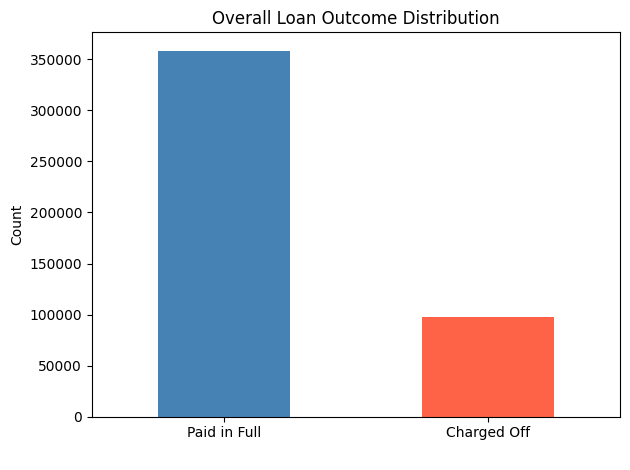

In [ ]:
# Overall Default Rate
df['ChargedOff'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Overall Loan Outcome Distribution')
plt.xticks([0, 1], ['Paid in Full', 'Charged Off'], rotation=0)
plt.xlabel(' ')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Your cleaned full dataset has roughly 360,000 paid in full and 100,000 charged off loans. This means:

About 78% of loans were repaid successfully
About 22% defaulted

 This is my baseline default rate. Every comparison made from here — franchise vs independent, by industry, by loan size — should be read against this 22% baseline. If a group has a default rate above 22%, it's riskier than average. Below 22%, it's safer.

**For the ML model:** This is a moderately imbalanced dataset. Your model will naturally be better at predicting "Paid in Full" simply because there are 3.5x more of those cases. This is why you use ROC-AUC as your evaluation metric rather than just accuracy — a model that predicted "Paid in Full" for every single loan would be 78% accurate but completely useless

Franchise vs Independent Default Rate

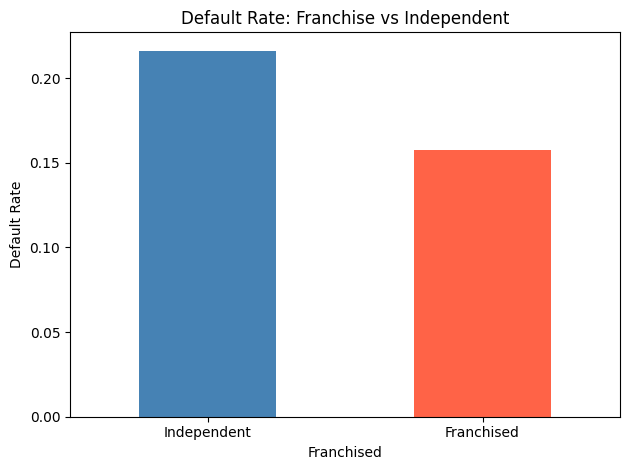

In [ ]:
# Re-create the 'Franchised' column correctly as it was inadvertently converted to NaNs in an earlier step.
df['Franchised'] = df['FranchiseCode'].apply(
    lambda x: 0 if str(x).strip() in ['0', '1', '00000', '00001'] else 1
)
df.groupby('Franchised')['ChargedOff'].mean().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Default Rate: Franchise vs Independent')
plt.xticks([0, 1], ['Independent', 'Franchised'], rotation=0)
plt.ylabel('Default Rate')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2221/3445135957.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_default, x='ChargedOff',


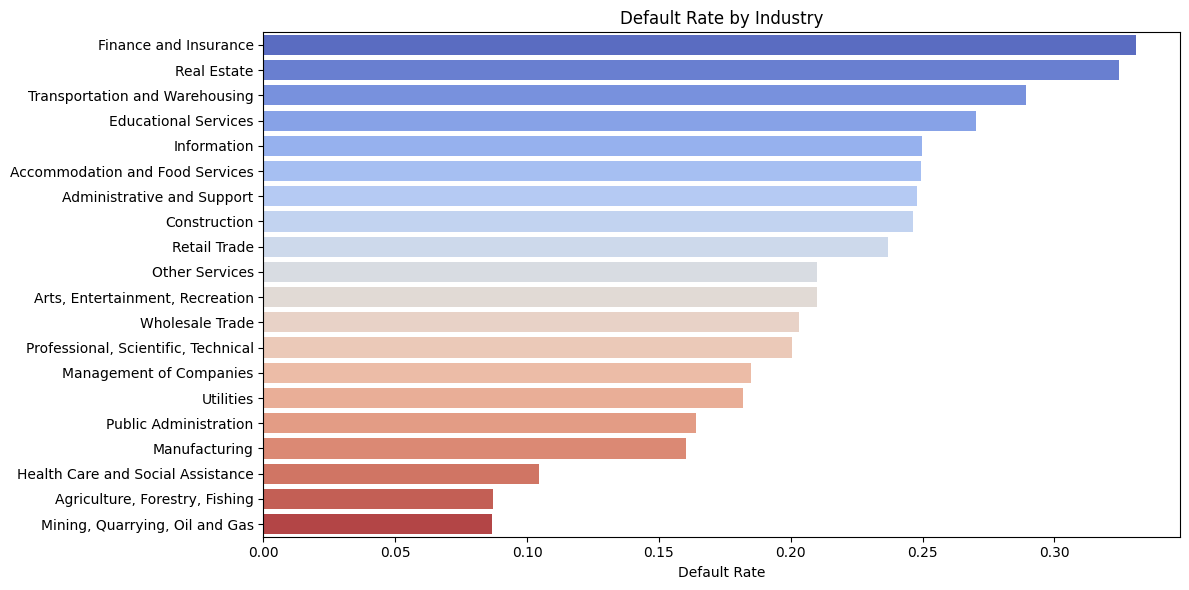

In [ ]:
# Default Rate by Industry
industry_default = (df.groupby('NAICS_2Digit_Title')['ChargedOff']
                    .mean()
                    .sort_values(ascending=False)
                    .reset_index())

plt.figure(figsize=(12, 6))
sns.barplot(data=industry_default, x='ChargedOff',
            y='NAICS_2Digit_Title', palette='coolwarm')
plt.title('Default Rate by Industry')
plt.xlabel('Default Rate')
plt.ylabel('')
plt.tight_layout()
plt.show()

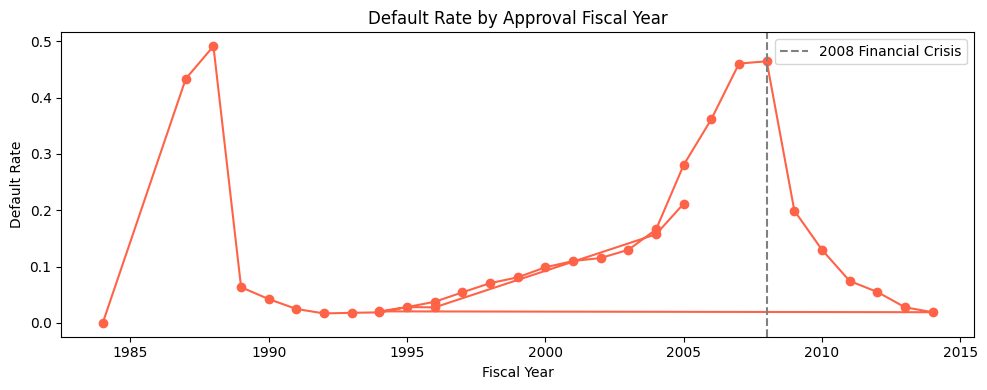

In [ ]:
time_default = df.groupby('ApprovalFY')['ChargedOff'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(time_default['ApprovalFY'], time_default['ChargedOff'],
         marker='o', color='tomato')
plt.axvline(x=2008, color='gray', linestyle='--', label='2008 Financial Crisis')
plt.title('Default Rate by Approval Fiscal Year')
plt.xlabel('Fiscal Year')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

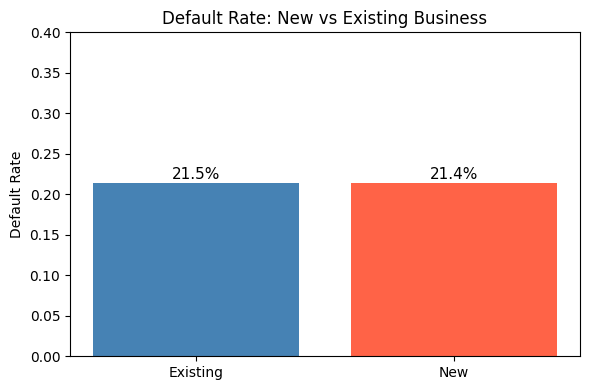

In [ ]:
new_exist_default = df.groupby('NewExist')['ChargedOff'].mean().reset_index()
new_exist_default['Label'] = new_exist_default['NewExist'].map({0: 'Existing', 1: 'New'})

plt.figure(figsize=(6, 4))
bars = plt.bar(new_exist_default['Label'],
               new_exist_default['ChargedOff'],
               color=['steelblue', 'tomato'])
plt.title('Default Rate: New vs Existing Business')
plt.ylabel('Default Rate')
plt.ylim(0, 0.4)
for bar, rate in zip(bars, new_exist_default['ChargedOff']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{rate:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
print(df['NewExist'].value_counts())

NewExist
0    335295
1    120979
Name: count, dtype: int64


"Business age (new vs existing) showed virtually no difference in default rates — 21.5% vs 21.4% respectively — suggesting it is not a meaningful standalone predictor of loan default."

The LowDoc program is a simplified loan application where borrowers submit less
paperwork. The assumption would be that less documentation = more risk = more defaults. The data says the opposite. **It shows that standard loans are more likely to default than simplified loan applications. **

Selection bias
Businesses that qualify for LowDoc tend to be more established with simpler financial profiles — not necessarily riskier borrowers.

The program was discontinued
The SBA phased out LowDoc after the 2008 crisis, so most of those loans in the dataset are older and from a more stable economic period.

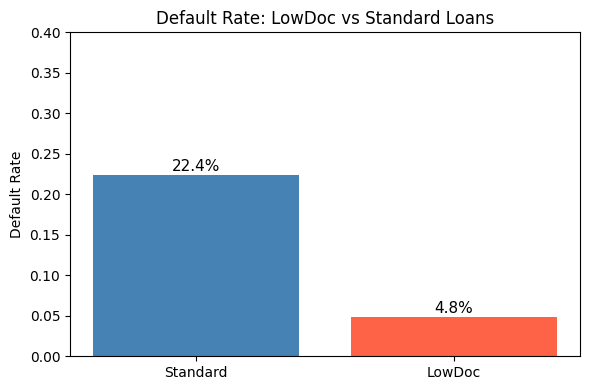

In [ ]:
lowdoc_default = df.groupby('LowDoc')['ChargedOff'].mean().reset_index()
lowdoc_default['Label'] = lowdoc_default['LowDoc'].map({1: 'LowDoc', 0: 'Standard'})

plt.figure(figsize=(6, 4))
bars = plt.bar(lowdoc_default['Label'],
               lowdoc_default['ChargedOff'],
               color=['steelblue', 'tomato'])
plt.title('Default Rate: LowDoc vs Standard Loans')
plt.ylabel('Default Rate')
plt.ylim(0, 0.4)
for bar, rate in zip(bars, lowdoc_default['ChargedOff']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{rate:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

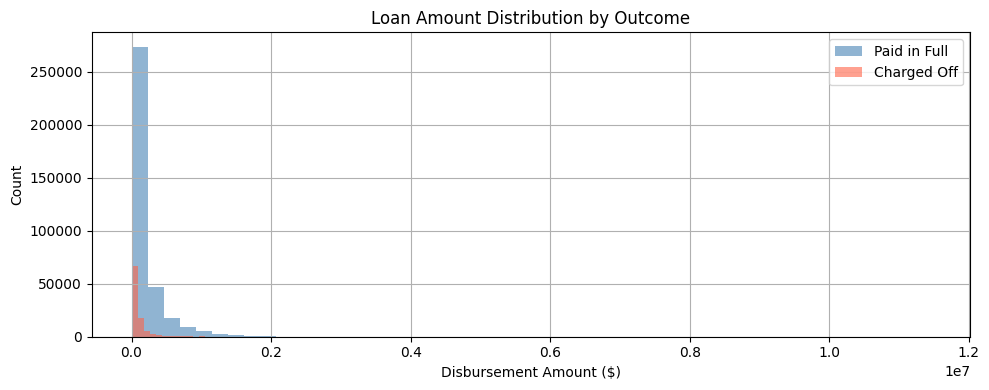

In [ ]:
plt.figure(figsize=(10, 4))
df[df['ChargedOff'] == 0]['DisbursementGross'].hist(
    bins=50, alpha=0.6, label='Paid in Full', color='steelblue')
df[df['ChargedOff'] == 1]['DisbursementGross'].hist(
    bins=50, alpha=0.6, label='Charged Off', color='tomato')
plt.title('Loan Amount Distribution by Outcome')
plt.xlabel('Disbursement Amount ($)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

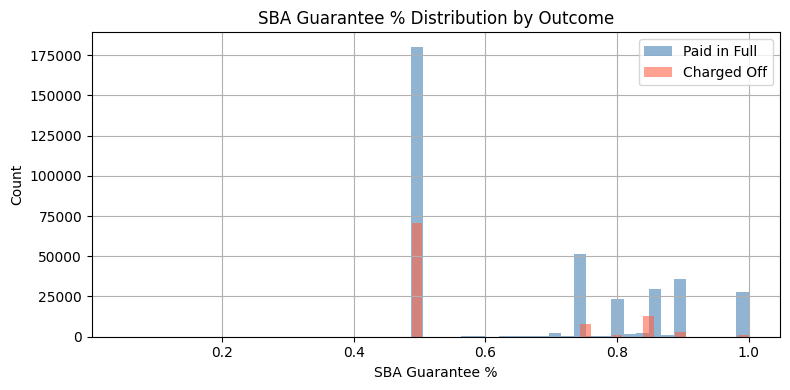

In [ ]:
plt.figure(figsize=(8, 4))
df[df['ChargedOff'] == 0]['SBA_Guarantee_Pct'].hist(
    bins=50, alpha=0.6, label='Paid in Full', color='steelblue')
df[df['ChargedOff'] == 1]['SBA_Guarantee_Pct'].hist(
    bins=50, alpha=0.6, label='Charged Off', color='tomato')
plt.title('SBA Guarantee % Distribution by Outcome')
plt.xlabel('SBA Guarantee %')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

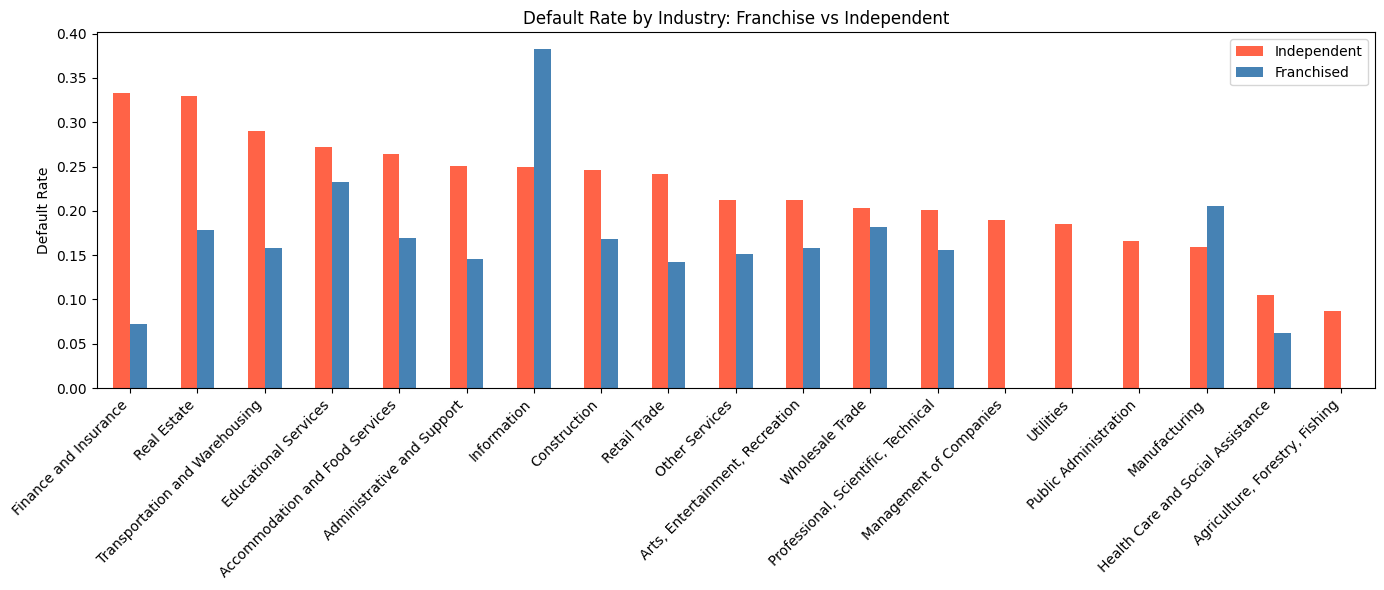

In [ ]:
franchise_industry = df.groupby(
    ['NAICS_2Digit_Title', 'Franchised'])['ChargedOff'].mean().unstack()
franchise_industry.columns = ['Independent', 'Franchised']
franchise_industry = franchise_industry.dropna().sort_values('Independent', ascending=False)

franchise_industry.plot(kind='bar', figsize=(14, 6),
                        color=['tomato', 'steelblue'])
plt.title('Default Rate by Industry: Franchise vs Independent')
plt.xlabel('')
plt.ylabel('Default Rate')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

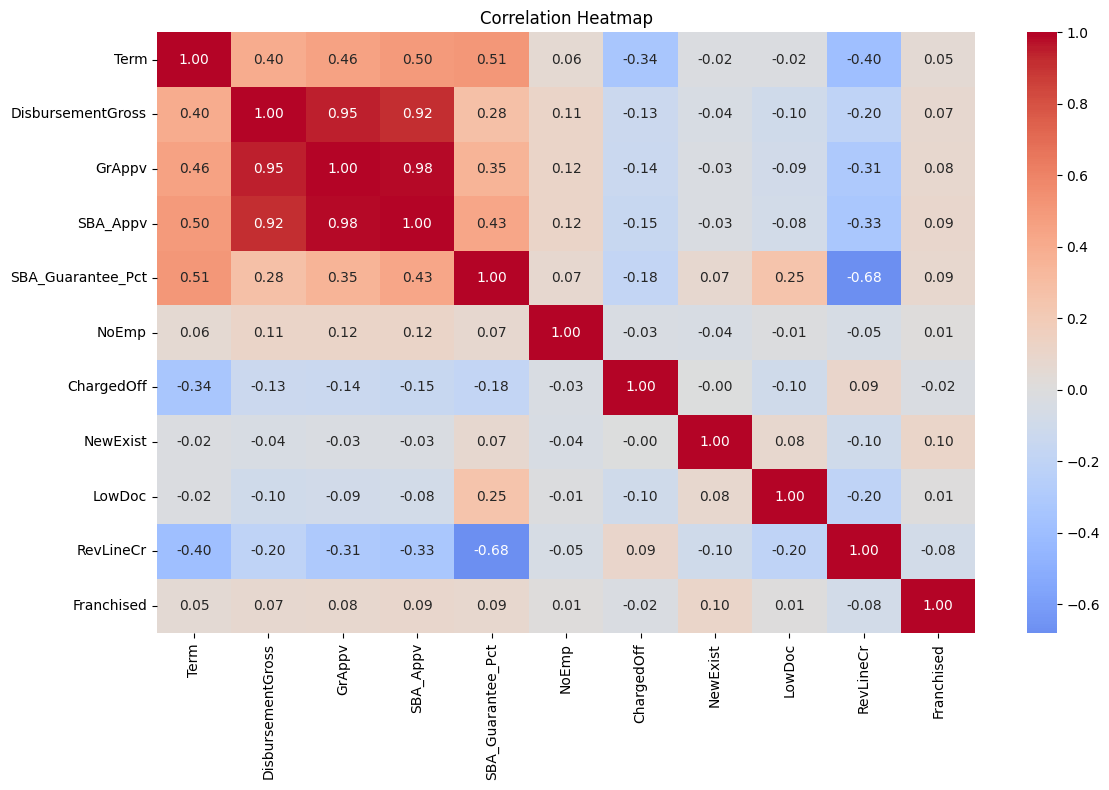

In [ ]:
numeric_cols = ['Term', 'DisbursementGross', 'GrAppv', 'SBA_Appv',
                'SBA_Guarantee_Pct', 'NoEmp', 'ChargedOff',
                'NewExist', 'LowDoc', 'RevLineCr', 'Franchised']

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## **ML Preparation**

Select Features and Targets

In [ ]:
features = ['Franchised', 'NewExist', 'Term', 'DisbursementGross',
            'GrAppv', 'SBA_Guarantee_Pct', 'LowDoc', 'RevLineCr',
            'UrbanRural', 'NoEmp', 'NAICS_2Digit_Code', 'ApprovalFY']

X = df[features].copy()
y = df['ChargedOff']

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts(normalize=True)}')

X shape: (456274, 12)
y distribution:
ChargedOff
0    0.785616
1    0.214384
Name: proportion, dtype: float64


Encode Categoricals

In [ ]:
X = pd.get_dummies(X, columns=['NAICS_2Digit_Code', 'UrbanRural'],
                   drop_first=True)
print(f'X shape after encoding: {X.shape}')

X shape after encoding: (456274, 35)


**Train/Test Split **

We use a 70/30 split given the large data set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (319391, 35)
Test: (136883, 35)


## **Normalization**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Training**

In [ ]:
# Train 3 Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': roc_auc_score(y_test, y_prob)}
    print(f'AUC: {results[name]["auc"]:.4f}\n')

Training Logistic Regression...
AUC: 0.8564

Training Decision Tree...
AUC: 0.9469

Training Random Forest...
AUC: 0.9701



In [ ]:
# Classification Reports
for name, result in results.items():
    print(f'\n{name} — AUC: {result["auc"]:.4f}')
    print(classification_report(y_test, result['y_pred'], target_names=['Paid in Full', 'Charged Off']))


Logistic Regression — AUC: 0.8564
              precision    recall  f1-score   support

Paid in Full       0.85      0.95      0.89    107537
 Charged Off       0.66      0.38      0.49     29346

    accuracy                           0.83    136883
   macro avg       0.75      0.66      0.69    136883
weighted avg       0.81      0.83      0.81    136883


Decision Tree — AUC: 0.9469
              precision    recall  f1-score   support

Paid in Full       0.93      0.95      0.94    107537
 Charged Off       0.81      0.74      0.77     29346

    accuracy                           0.91    136883
   macro avg       0.87      0.85      0.86    136883
weighted avg       0.90      0.91      0.91    136883


Random Forest — AUC: 0.9701
              precision    recall  f1-score   support

Paid in Full       0.95      0.97      0.96    107537
 Charged Off       0.88      0.81      0.85     29346

    accuracy                           0.94    136883
   macro avg       0.92      0.89  

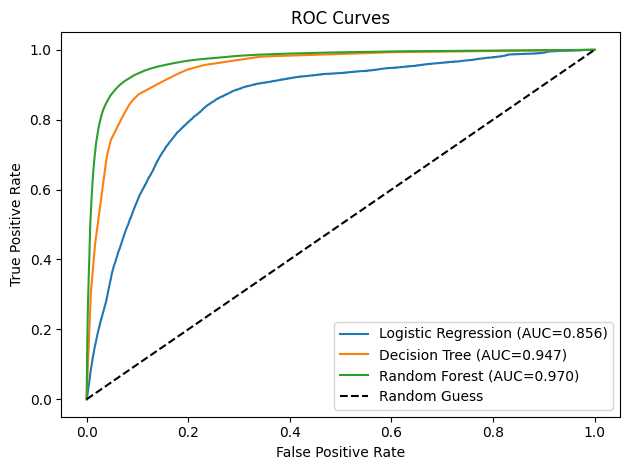

In [ ]:
# ROC Curves
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={result["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

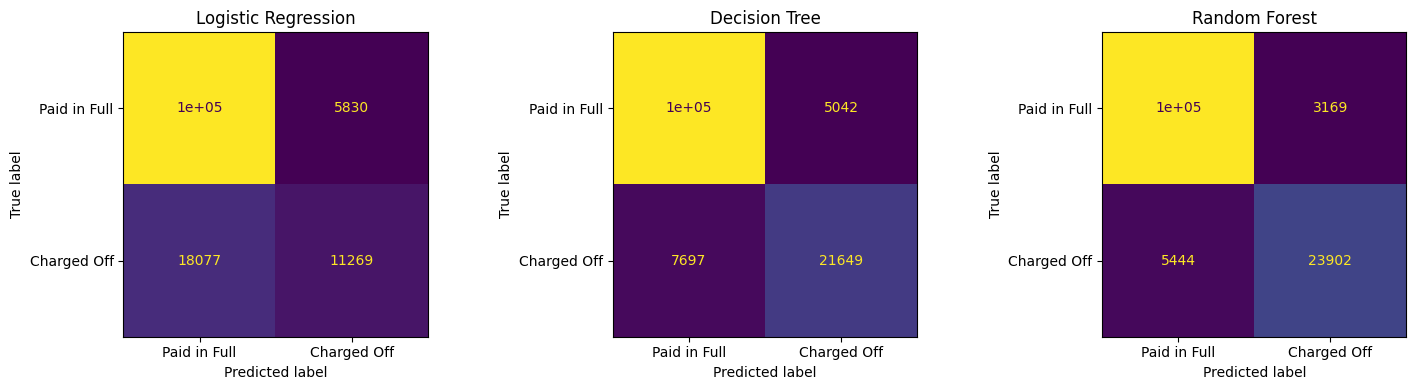

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, result) in zip(axes, results.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, result['y_pred']),
                           display_labels=['Paid in Full', 'Charged Off']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

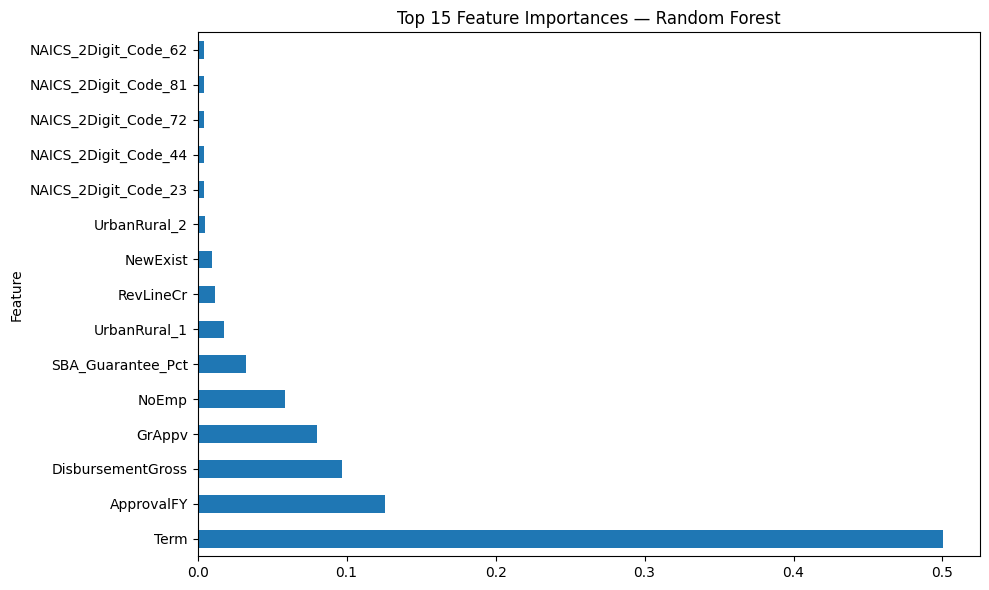

In [ ]:
# Feature Importance
pd.DataFrame({
    'Feature': X.columns,
    'Importance': results['Random Forest']['model'].feature_importances_
}).sort_values('Importance', ascending=False).head(15).plot(kind='barh', x='Feature', y='Importance', figsize=(10, 6), legend=False)
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

## **Clustering**

In [ ]:
from sklearn.cluster import KMeans

cluster_features = ['DisbursementGross', 'Term', 'SBA_Guarantee_Pct', 'NoEmp', 'Franchised', 'NewExist']
cluster_df = df[cluster_features].dropna().copy()

cluster_scaled = MinMaxScaler().fit_transform(cluster_df)
cluster_df['Cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(cluster_scaled)

print(cluster_df.groupby('Cluster').mean().round(3))

         DisbursementGross     Term  SBA_Guarantee_Pct   NoEmp  Franchised  \
Cluster                                                                      
0               145225.668   90.637              0.668   5.596         0.0   
1                96036.429   62.925              0.500   7.119         0.0   
2               291329.449  138.423              0.846  17.103         0.0   
3               280051.529  114.257              0.739  13.005         1.0   

         NewExist  
Cluster            
0           1.000  
1           0.000  
2           0.000  
3           0.517  


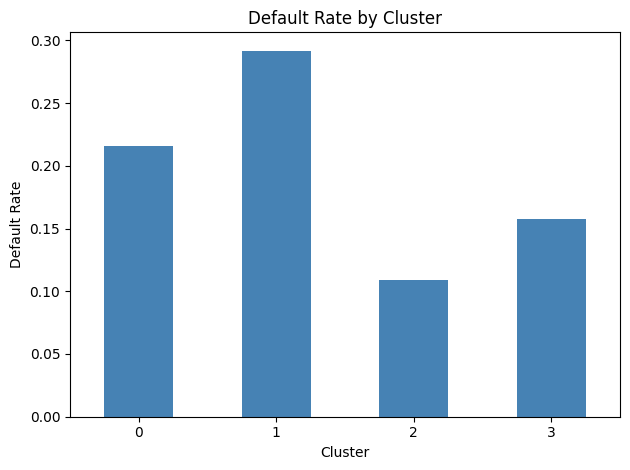

In [ ]:
df_clustered = df.loc[cluster_df.index].copy()
df_clustered['Cluster'] = cluster_df['Cluster']

df_clustered.groupby('Cluster')['ChargedOff'].mean().plot(kind='bar', color='steelblue')
plt.title('Default Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Fill these in after reviewing the cluster profile printout above
cluster_names = {0: 'Name 0', 1: 'Name 1', 2: 'Name 2', 3: 'Name 3'}
df_clustered['Cluster_Name'] = df_clustered['Cluster'].map(cluster_names)

print(df_clustered.groupby('Cluster_Name').agg(
    Count=('ChargedOff', 'count'),
    Default_Rate=('ChargedOff', 'mean'),
    Avg_Loan=('DisbursementGross', 'mean'),
    Avg_Term=('Term', 'mean'),
    Pct_Franchised=('Franchised', 'mean')
).round(3))

               Count  Default_Rate    Avg_Loan  Avg_Term  Pct_Franchised
Cluster_Name                                                            
Name 0        113608         0.216  145225.668    90.637             0.0
Name 1        192451         0.292   96036.429    62.925             0.0
Name 2        135965         0.109  291329.449   138.423             0.0
Name 3         14250         0.157  280051.529   114.257             1.0


In [ ]:
# Checking for data leakages

#print(X.columns.tolist())

# Verify if target is separate
print(y.name)          # should print 'ChargedOff'
print(y.value_counts(normalize=True))  # should show ~78/22 split

ChargedOff
ChargedOff
0    0.785616
1    0.214384
Name: proportion, dtype: float64


These should not appear:


1. MIS_Status      ← source of your target variable
2. ChgOffDate      ← only exists after default
3. ChgOffPrinGr    ← only exists after default
4. BalanceGross    ← reflects outcome
5. ChargedOff      ← this IS your target variable


## **Stress Testing the Model**

In [ ]:
# Test 1 - Overfitting Check
for name, result in results.items():
    train_pred = result['model'].predict_proba(X_train_scaled)[:, 1]
    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = result['auc']
    gap = train_auc - test_auc
    print(f'{name}')
    print(f'Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f} | Gap: {gap:.4f}')
    print('⚠️ Overfitting' if gap > 0.05 else '✓ Good')
    print()

Logistic Regression
Train AUC: 0.8567 | Test AUC: 0.8564 | Gap: 0.0004
✓ Good

Decision Tree
Train AUC: 0.9465 | Test AUC: 0.9469 | Gap: -0.0004
✓ Good

Random Forest
Train AUC: 1.0000 | Test AUC: 0.9701 | Gap: 0.0299
✓ Good



In [ ]:
# Test 2 - Dummy Baseline
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_dummy = dummy.predict(X_test_scaled)
print('Dummy Classifier Baseline:')
print(classification_report(y_test, y_dummy,
      target_names=['Paid in Full', 'Charged Off']))

Dummy Classifier Baseline:
              precision    recall  f1-score   support

Paid in Full       0.79      1.00      0.88    107537
 Charged Off       0.00      0.00      0.00     29346

    accuracy                           0.79    136883
   macro avg       0.39      0.50      0.44    136883
weighted avg       0.62      0.79      0.69    136883



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Test 3 - Cross Validation
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    print(f'{name}')
    print(f'AUC per fold: {scores.round(3)}')
    print(f'Mean AUC: {scores.mean():.3f} (+/- {scores.std():.3f})\n')

Logistic Regression
AUC per fold: [0.856 0.858 0.857 0.856 0.856]
Mean AUC: 0.857 (+/- 0.001)

Decision Tree
AUC per fold: [0.946 0.947 0.947 0.946 0.946]
Mean AUC: 0.946 (+/- 0.000)



/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest
AUC per fold: [0.969 0.969 0.971 0.97  0.969]
Mean AUC: 0.969 (+/- 0.001)

